In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('quikr_car.csv')

In [3]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [4]:
df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [5]:
df = df[df['kms_driven'].notnull()]

In [6]:
df = df[df['fuel_type'].notnull()]

In [7]:
df = df[df['Price'] != "Ask For Price"]

In [8]:
df.isnull().sum()

name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64

In [9]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
6,Ford Figo,Ford,2012,"1,75,000","41,000 kms",Diesel


In [10]:
df['Price']=df['Price'].str.replace(',','').astype(int)
df['kms_driven']=df['kms_driven'].str.split().str.get(0).str.replace(',','')

In [11]:
df=df[df['kms_driven'].str.isnumeric()]

In [12]:
df=df[df['year'].str.isnumeric()]

In [42]:
df['kms_driven']=df['kms_driven'].astype(int)
df['year']=df['year'].astype(int)
df['age'] = 2019 - df['year']

In [43]:
df['fuel_type'].unique()

array(['Petrol', 'Diesel', 'LPG'], dtype=object)

In [44]:
df['name']=df['name'].str.split().str.slice(start=0,stop=3).str.join(' ')

In [45]:
df.describe(include='all')

,name,company,year,Price,kms_driven,fuel_type,age
count,815,815,815.000000,8.150000e+02,815.000000,815,815.000000
unique,254,25,NaN,NaN,NaN,3,NaN
top,Maruti Suzuki Swift,Maruti,NaN,NaN,NaN,Petrol,NaN
freq,51,221,NaN,NaN,NaN,428,NaN
mean,NaN,NaN,2012.442945,4.017933e+05,46277.096933,NaN,6.557055
std,NaN,NaN,4.005079,3.815888e+05,34318.459638,NaN,4.005079
min,NaN,NaN,1995.000000,3.000000e+04,0.000000,NaN,0.000000
25%,NaN,NaN,2010.000000,1.750000e+05,27000.000000,NaN,4.000000
50%,NaN,NaN,2013.000000,2.999990e+05,41000.000000,NaN,6.000000
75%,NaN,NaN,2015.000000,4.900000e+05,56879.000000,NaN,9.000000


In [46]:
import seaborn as sns

<Axes: xlabel='Price', ylabel='Count'>

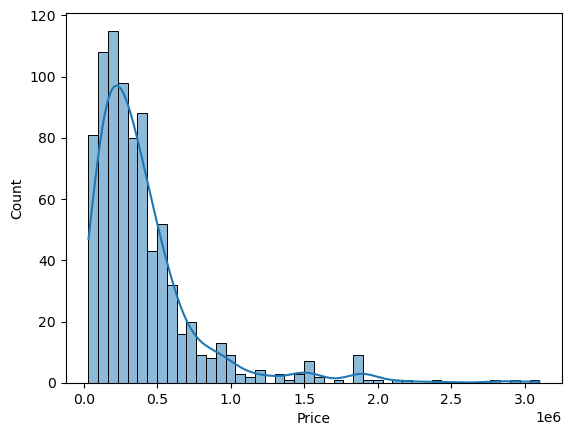

In [47]:
sns.histplot(data=df, x="Price", kde=True)

In [48]:
df = df[df['Price'] < 6000000]
df['Price'] = df['Price'].astype(int)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 815 entries, 0 to 889
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        815 non-null    object
 1   company     815 non-null    object
 2   year        815 non-null    int64 
 3   Price       815 non-null    int64 
 4   kms_driven  815 non-null    int64 
 5   fuel_type   815 non-null    object
 6   age         815 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 50.9+ KB


In [50]:
df

,name,company,year,Price,kms_driven,fuel_type,age
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol,12
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel,13
3,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol,5
4,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel,5
6,Ford Figo,Ford,2012,175000,41000,Diesel,7
...,...,...,...,...,...,...,...
883,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol,8
885,Tata Indica V2,Tata,2009,110000,30000,Diesel,10
886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol,10
888,Tata Zest XM,Tata,2018,260000,27000,Diesel,1


In [65]:
X = df[['name','company','age','kms_driven','fuel_type']]
y = df['Price']

In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state= 42)

In [67]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [68]:
ohe = OneHotEncoder()

In [69]:
ohe.fit(X[['name','company','fuel_type']])

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [70]:
ct = make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                             (StandardScaler(), ['kms_driven']),remainder='passthrough')

In [71]:
lr = LinearRegression()

In [72]:
pipe = make_pipeline(ct,lr)

In [73]:
pipe.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [74]:
y_pred=pipe.predict(X_test)

In [75]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(ct,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [76]:
np.argmax(scores)

np.int64(655)

In [77]:
scores[np.argmax(scores)]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(ct,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

0.9198131290058257

In [78]:
import pickle

In [79]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [80]:
X

,name,company,age,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,12,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,13,40,Diesel
3,Hyundai Grand i10,Hyundai,5,28000,Petrol
4,Ford EcoSport Titanium,Ford,5,36000,Diesel
6,Ford Figo,Ford,7,41000,Diesel
...,...,...,...,...,...
883,Maruti Suzuki Ritz,Maruti,8,50000,Petrol
885,Tata Indica V2,Tata,10,30000,Diesel
886,Toyota Corolla Altis,Toyota,10,132000,Petrol
888,Tata Zest XM,Tata,1,27000,Diesel


In [82]:
pipe.predict(pd.DataFrame(columns=['name','company','age','kms_driven','fuel_type'],data=np.array(['Maruti Suzuki Swift','Maruti',0,100,'Petrol']).reshape(1,5)))

array([416656.50410286])

In [84]:
pd.DataFrame(y).skew()

Price    2.892155
dtype: float64

<Axes: xlabel='Price', ylabel='Count'>

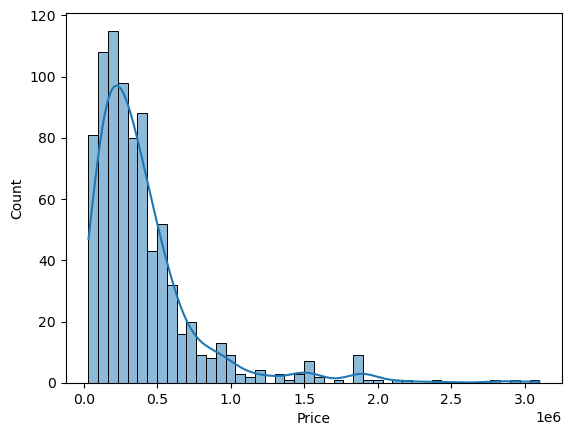

In [85]:
sns.histplot(data=y, kde=True)